# Retriever Evaluation Pipeline (Consolidated)

This notebook evaluates the performance of `dense`, `sparse`, `ensemble`, and `hybrid` retrievers.
It uses a simplified Python loop instead of LangGraph.

**Metrics:**
- Hit Rate@TopK
- NDCG@TopK
- Accuracy@Top1
- Relevance Score (LLM Judge 0-5)

In [1]:
import sys
import os
import random
import math
import asyncio
from typing import List, Dict, Any
from tabulate import tabulate
from sqlalchemy import text

# Ensure project root is in sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from langchain_upstage import ChatUpstage
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field

from app.core.config import settings
from app.db.session import SessionLocal
from app.db.vector_db import (
    get_dense_retriever,
    get_sparse_retriever,
    get_ensemble_retriever,
    get_hybrid_retriever,
    get_dense_multi_query_retriever,
    get_multi_query_ensemble_retriever,
    get_hyde_retriever,
    get_cohere_reranker_retriever,
    get_hybrid_hyde_retriever
)

e:\pythonProject\P-plip-inference\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Setup & Configuration

In [2]:
def get_llm(model="solar-pro2"):
    # Use solar-pro as configured
    return ChatUpstage(api_key=settings.UPSTAGE_API_KEY, model=model)

## 2. Helper Functions: Data Gen & Metrics

In [3]:
# # === Data Generation ===

# def get_random_attractions(limit: int = 1):
#     """
#     Fetch random attractions from DB.
#     """
#     db = SessionLocal()
#     try:
#         query = text(
#             """
#             SELECT no, title, overview 
#             FROM attractions 
#             WHERE overview IS NOT NULL AND overview != '' 
#             AND ST_Distance_Sphere(
#                 POINT(longitude, latitude), 
#                 POINT(:user_lng, :user_lat)
#             ) <= (:radius_km * 1000)
#             ORDER BY RAND() 
#             LIMIT :limit
#             """
#         )
#         result = db.execute(query, {"limit": limit, "user_lat": 37.5666, "user_lng": 126.9780, "radius_km": 3}).fetchall()
#         return [
#             {"no": row.no, "title": row.title, "overview": row.overview}
#             for row in result
#         ]
#     finally:
#         db.close()


# def check_hit_rate(ground_truth_id: int, retrieved_docs: list) -> int:
#     for doc in retrieved_docs:
#         retrieved_id = doc.metadata.get("no")
#         if str(retrieved_id) == str(ground_truth_id):
#             return 1
#     return 0

# def calculate_ndcg(ground_truth_id: int, retrieved_docs: list) -> float:
#     for i, doc in enumerate(retrieved_docs):
#         retrieved_id = doc.metadata.get("no")
#         if str(retrieved_id) == str(ground_truth_id):
#             rank = i + 1
#             return 1.0 / math.log2(rank + 1)
#     return 0.0

# def calculate_top1_accuracy(ground_truth_id: int, retrieved_docs: list) -> int:
#     if not retrieved_docs:
#         return 0
#     top_doc = retrieved_docs[0]
#     retrieved_id = top_doc.metadata.get("no")
#     if str(retrieved_id) == str(ground_truth_id):
#         return 1
#     return 0

In [4]:
from langchain_core.output_parsers import ListOutputParser, StrOutputParser
def generate_synthetic_query(category: str, k=5) -> str:
    """
    Generate a search query based on overview using LLM.
    """
    llm = get_llm()
    prompt = ChatPromptTemplate.from_messages([
        ("system", """
        [역할]
        당신은 관광지를 찾고싶은 여행객입니다.
        제시된 [카테고리]를 방문하고 싶어하는 사용자들이 던질 법한 질문을 {k}개 생성하세요. 반드시 {k}개를 생성해야합니다.
        단, 카테고리별로 세부적인 유형을 나누어서 질문을 생성하세요
        예를 들어 음식점의 경우 카페, 한식집, 양식집, 일식 전문점 등
        쇼핑의 경우 백화점, 전통시장등의 세부 유형을 나누어 질문을 생성하세요.
        
        [지침]
        1. 질문은 친구나 AI에게 말하는 듯한 자연스러운 구어체여야 합니다.
        2. 특정 장소 이름이나 특정 지역명(예: 종로, 시청)은 절대 포함하지 마세요.
        3. 각 질문은 서로 다른 상황(예: 혼자, 가족과, 데이트, 비즈니스 등)을 가정하여 다양하게 만드세요.
        4. 답변은 오직 질문 내용만 출력하며, 각 질문은 줄바꿈으로 구분하세요.      
        5. 절대로 부가적인 설명이나 번호등을 붙이지말고 정확히 5줄이 나오도록 출력하세요.  
        [카테고리]: {category}
        """),
    ])

    # [수정] StrOutputParser를 사용하여 결과를 문자열로 받음
    chain = prompt | llm | StrOutputParser()
    
    print(f"✍️ {category} 관련 가상 질문 생성 중...")
    raw_response = chain.invoke({"category": category, "k": k})
    
    # 줄바꿈으로 쪼개고 빈 줄은 제거하여 리스트 반환
    queries = [q.strip() for q in raw_response.strip().split('\n') if q.strip()]
    return queries[:k] # 정확히

## 3. Main Evaluation Logic

In [5]:
# async def run_single_evaluation(query: str, gt_id: int, k: int=5):
#     """
#     Runs 4 retrievers and evaluates metrics for each.
#     Returns a dict of results.
#     """
#     # 1. Initialize Retrievers
#     # Note: VectorStore creation is cached or cheap enough in this context
# #    filter = create_geo_radius_filter(lat=37.5666, lon=126.9780, radius_km=3)
#     retrievers = {a
#         "dense": get_dense_retriever(k=k),
#         "sparse": get_sparse_retriever(k=k),
#         "ensemble": get_ensemble_retriever(k=k),
#         "hybrid": get_hybrid_retriever(k=k),
#         "multi_query_dense": get_dense_multi_query_retriever(k=k, llm=get_llm()),
#         "multi_query_ensemble": get_multi_query_ensemble_retriever(k=k, llm=get_llm()),
#     }
    
#     results = {}
    
#     for name, retriever in retrievers.items():
#         # Retrieve (async invoke if possible, else invoke)
#         docs = await retriever.ainvoke(query)
        
#         # Metrics
#         hit = check_hit_rate(gt_id, docs)
#         ndcg = calculate_ndcg(gt_id, docs)
#         acc = calculate_top1_accuracy(gt_id, docs)
        
#         # LLM Judge on Top-1
#         if docs:
#             top_doc = docs[0]
#             content = f"Title: {top_doc.metadata.get('title')}\nOverview: {top_doc.metadata.get('overview')}"
#             #eval_res = evaluate_relevance(query, content)
#             #score = eval_res.score
#         else:
#             score = 0
            
#         results[name] = {
#             "hit_rate": hit,
#             "ndcg": ndcg,
#             "accuracy": acc,
#             #"score": score
#         }
        
#     return results

## 4. Run Experiment

In [6]:
# import logging

# logging.basicConfig()
# logging.getLogger("langchain.retrievers.multi_query").setLevel(logging.INFO)

In [7]:
num_samples = 10
#attractions = get_random_attractions(limit=num_samples)
categories = ["관광지","문화시설","축제공연행사","여행코스","레포츠","숙박","쇼핑","음식점"]
dataset = []

print(f"Generated categories {categories} with {num_samples} samples:")
for category in categories:
    query = generate_synthetic_query(category, num_samples)
    dataset.extend(query)
    print(f"- [{category}] Q: {query}")

print(f"최종 데이터 : {dataset}")

Generated categories ['관광지', '문화시설', '축제공연행사', '여행코스', '레포츠', '숙박', '쇼핑', '음식점'] with 10 samples:
✍️ 관광지 관련 가상 질문 생성 중...
- [관광지] Q: ['자연경관이 예쁜 관광지 중 가족과 함께 가기 좋은 곳은 어디가 있을까요?', '혼자 여행가서 역사 유적지를 탐방하기 좋은 곳을 추천해 주세요.', '커플이 함께 가볼 만한 로맨틱한 관광지가 있을까요?', '아이들과 함께 체험할 수 있는 교육적인 관광지를 찾고 있어요.', '비즈니스 미팅 후 가볍게 둘러보기 좋은 도시 속 관광지가 있을까요?', '야경이 아름다운 자연 관광지를 추천해 주실 수 있나요?', '전통 문화를 경험할 수 있는 관광지 중 외국인이 방문하기 편한 곳은요?', '도심에서 멀지 않은 산책하기 좋은 공원이 있을까요?', '특이한 암석이나 지형을 볼 수 있는 관광지를 알려주세요.', '계절별로 다른 매력을 느낄 수 있는 관광지 추천 부탁드립니다.']
✍️ 문화시설 관련 가상 질문 생성 중...
- [문화시설] Q: ['문화시설에서 가족이나 친구와 함께 체험할 수 있는 전통 공예 프로그램이 있을까요?', '혼자 방문하기 좋은 조용한 미술관이나 박물관이 있을까요?', '데이트 코스로 적합한 야간 개장 문화시설이 있을까요?', '아이와 함께 가면 좋을 체험형 전시나 교육 프로그램이 있는 곳이 있을까요?', '비즈니스 미팅 후 가볍게 들르기 좋은 현대적인 갤러리나 복합 문화공간이 있을까요?', '역사 테마로 된 문화시설 중에서 사진 찍기 좋은 곳을 추천해 주세요.', '문화시설 중에서 반려동물과 함께 입장 가능한 곳이 있을까요?', '대중교통으로 접근하기 편한 문화시설 중 야외 공연장이 있을까요?', '문화시설 내에서 식사나 커피까지 함께 즐길 수 있는 복합 공간이 있을까요?', '문화시설 중 계절별로 특별 행사를 하는 곳을 알고 있나요?']
✍️ 축제공연행사 관련 가상 질문 생성 중...
- [축제공연행사] Q: [

## 평가자 설정

In [8]:
import pandas as pd
import asyncio
from datasets import Dataset
from tabulate import tabulate
from ragas import evaluate
from ragas.run_config import RunConfig
from langchain_openai import ChatOpenAI
from ragas.metrics import AspectCritic
from app.db.filters import create_geo_radius_filter
from langchain_upstage.embeddings import UpstageEmbeddings
import os
from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv())
filter = create_geo_radius_filter(lat=37.5666, lon=126.9780, radius_km=10)


C:\Users\minj2\AppData\Local\Temp\ipykernel_20880\1848299209.py:8: DeprecationWarning: Importing AspectCritic from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import AspectCritic
  from ragas.metrics import AspectCritic


## 검색 함수

In [9]:

from langchain_upstage import ChatUpstage

async def fetch_retrieval_results(dataset, k=5, filter=None):
    """
    1단계: 리트리버 초기화 및 병렬 검색 수행
    """
    # 리트리버 초기화
    retrievers = {
        "ensemble": get_ensemble_retriever(k=k, dense_weight=0.8, sparse_weight=0.2),
        "hybrid_hyde": get_hybrid_hyde_retriever(k=k, llm=get_llm(model="solar-pro2")),
        "hybrid": get_hybrid_retriever(k=k),
        "hyde": get_hyde_retriever(k=k, llm=get_llm(model="solar-pro2")),
        "dense": get_dense_retriever(k=k),
        "sparse": get_sparse_retriever(k=k),
     #   "reranker": get_cohere_reranker_retriever(top_k=k),
    }
    retriever_names = list(retrievers.keys())
    ragas_data_collections = {name: [] for name in retriever_names}

    print(f"🚀 총 {len(dataset)}개 샘플 검색 시작 (병렬 처리)...")

    for query in dataset:
        # asyncio.gather를 사용하여 모든 리트리버를 동시에 실행
        tasks = [retrievers[name].ainvoke(query) for name in retriever_names]
        results = await asyncio.gather(*tasks)

        for name, docs in zip(retriever_names, results):
            combined_contexts = [
                f"장소명: {doc.metadata.get('title', 'N/A')}\n내용: {doc.metadata.get('overview', '')}" 
                for doc in docs
            ]
            scores = [doc.metadata.get("_score", 0) for doc in docs]
            ragas_data_collections[name].append({
                "user_input": query,
                "retrieved_contexts": combined_contexts,
                "scores": scores
            })
        
    return ragas_data_collections
    

## 평가 함수

In [10]:
# 1. Evaluator Setup (Upstage Solar Model and Embeddings)
evaluator_llm = get_llm("solar-pro2") 

# 1. Category Alignment
category_alignment = AspectCritic(
    name="category_alignment",
    definition="""
    [Role]
    You are a 'Tourism Data Inspector' who has a perfect understanding of the classification system for 8 types of tourism (Tourist Attractions, Cultural Facilities, Festivals/Performances/Events, Travel Courses, Leisure/Sports, Accommodations, Shopping, and Restaurants).

    [Definition of Evaluation Categories]
    - Tourist Attractions: Places for sightseeing such as natural landscapes, historical sites, and parks.
    - Cultural Facilities: Facility-based cultural activities such as museums, art galleries, performance halls, and libraries.
    - Festivals/Performances/Events: Festivals or events held during a specific period.
    - Travel Courses: Recommended routes connecting multiple points.
    - Leisure/Sports: Activity and experience-centered locations such as surfing, skiing, and bungee jumping.
    - Accommodations: Places to stay overnight such as hotels, guesthouses, and campsites.
    - Shopping: Places for purchasing goods such as markets, duty-free shops, and souvenir shops.
    - Restaurants: Places for dining and drinking such as restaurants, cafes, and bakeries.

    [Evaluation Criteria: Strict Prohibition of Category Violation]
    1. First, identify the 'Target Type' explicitly stated or implied by the questioner.
    2. If the 'Dominant Identity' of the retrieved document differs from that type, it is immediately 0 points.
    3. Detect 'Association Errors' typical of Dense searches.
       - Example: If searching for "Accommodation with a sea view," a "Cafe with a sea view (Restaurant)" or "Sea Observatory (Tourist Attraction)" is 0 points.
       - Example: If searching for "Traditional Craft Shopping," a "Traditional Museum (Cultural Facility)" is 0 points.
    4. Ancillary facilities are not the primary identity. A restaurant inside a hotel is classified as 'Accommodation,' not a 'Restaurant.'

    [Scoring]
    - 1 point: The primary identity of the place perfectly matches the user's target type.
    - 0 points: The types are different, or a place of a different type was recommended simply because it has a 'similar vibe.'

    Let's think step by step.
    """,
    strictness=3
)

# 2. Vibe and Condition Relevance (Abstract Requirements Check)
vibe_relevance = AspectCritic(
    name="vibe_relevance",
    definition="""
    [Role]
    You are a 'Fact-Check Investigator' who verifies whether the user's requirements are explicitly stated in the document's text.

    [Evaluation Guidelines: Inference and Imagination Prohibited]
    1. Verify whether the constraints included in the question exist as explicit evidence within the document.
    2. Exclude your subjective common sense. Do not assume "It must be educational because it's a museum" or "The air must be fresh because it's a mountain." If the document does not describe those specific characteristics, it is 0 points.
    3. Even if the category is correct, if the detailed conditions differ, it is 0 points. (e.g., The user wants a 'quiet tourist attraction' but an 'active theme park' is retrieved.)

    [Passing Criteria: 1 point]
    - Specific descriptions or keywords supporting the atmosphere/conditions of the question actually exist in the document.
    [Failing Criteria: 0 points]
    - If the characteristics cannot be confirmed based solely on the document content.
    - If the actual nature of the place conflicts with the user's intent.

    Let's think step by step.
    """,
    strictness=3
)

In [11]:
from datasets import Dataset
from ragas import evaluate, RunConfig

def evaluate_ragas_data(ragas_data_collections, evaluator_llm, metrics):
    """
    2단계: 준비된 데이터를 기반으로 LLM 평가 수행
    """
    all_results_dfs = []
    
    for name, data_list in ragas_data_collections.items():
        print(f"⚖️ {name} 리트리버 LLM 평가 중...")
        ragas_ds = Dataset.from_list(data_list)
        
        result = evaluate(
            dataset=ragas_ds,
            metrics=metrics,
            llm=evaluator_llm,
            run_config=RunConfig(timeout=180, max_retries=20, max_workers=10) 
        )
        
        res_df = result.to_pandas()
        res_df['retriever_name'] = name
        all_results_dfs.append(res_df)
        
    return all_results_dfs

## 결과 요약 함수

In [12]:
import pandas as pd
from tabulate import tabulate

def summarize_evaluation_results(all_results_dfs):
    """
    3단계: 모든 결과를 합치고 리트리버별 통계 계산
    """
    # 모든 결과 합치기
    total_df = pd.concat(all_results_dfs, ignore_index=True)

    # 정량 지표 요약 (평균 계산)
    summary_stats = total_df.groupby('retriever_name').agg({
        'category_alignment': 'mean',
        'vibe_relevance': 'mean'
    }).reset_index()

    # 종합 점수 계산 (가중치 적용)
    summary_stats['Total_Score'] = (summary_stats['category_alignment'] * 0.7) + (summary_stats['vibe_relevance'] * 0.3)
    summary_stats = summary_stats.sort_values(by='Total_Score', ascending=False)

    print("\n📊 리트리버별 정량 성능 비교표:")
    print(tabulate(summary_stats, headers='keys', tablefmt='psql', showindex=False))
    
    return total_df, summary_stats

## 실행

In [13]:
# 1. 검색 수행
ragas_input_data = await fetch_retrieval_results(dataset, k=10)

🚀 Loading SPLADE Model... (This happens only once)
🚀 총 80개 샘플 검색 시작 (병렬 처리)...


In [14]:

# 2. 평가 수행
metrics = [category_alignment, vibe_relevance]
evaluated_dfs = evaluate_ragas_data(ragas_input_data, evaluator_llm, metrics)

⚖️ ensemble 리트리버 LLM 평가 중...


Evaluating: 100%|██████████| 160/160 [04:37<00:00,  1.73s/it]


⚖️ hybrid_hyde 리트리버 LLM 평가 중...


Evaluating: 100%|██████████| 160/160 [04:32<00:00,  1.70s/it]


⚖️ hybrid 리트리버 LLM 평가 중...


...

Evaluating: 100%|██████████| 160/160 [04:54<00:00,  1.84s/it]


⚖️ dense 리트리버 LLM 평가 중...


Evaluating: 100%|██████████| 160/160 [04:48<00:00,  1.80s/it]


⚖️ sparse 리트리버 LLM 평가 중...


Evaluating: 100%|██████████| 160/160 [04:30<00:00,  1.69s/it]



📊 리트리버별 정량 성능 비교표:
+------------------+----------------------+------------------+---------------+
| retriever_name   |   category_alignment |   vibe_relevance |   Total_Score |
|------------------+----------------------+------------------+---------------|
| ensemble         |               0.7625 |           0.8125 |       0.7775  |
| hybrid           |               0.75   |           0.8375 |       0.77625 |
| hyde             |               0.7625 |           0.7875 |       0.77    |
| hybrid_hyde      |               0.75   |           0.75   |       0.75    |
| dense            |               0.625  |           0.7375 |       0.65875 |
| sparse           |               0.6125 |           0.7    |       0.63875 |
+------------------+----------------------+------------------+---------------+


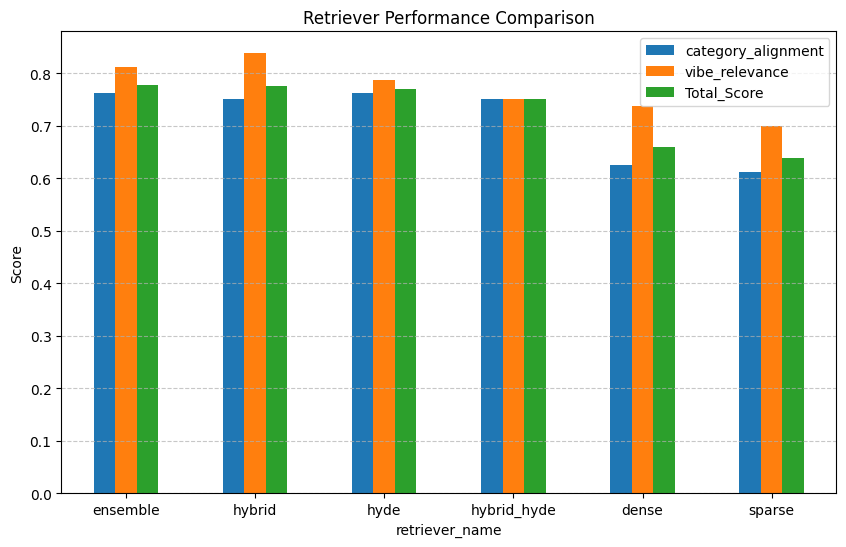

In [15]:

# 3. 결과 요약 및 시각화
total_df, summary_stats = summarize_evaluation_results(evaluated_dfs)

# 4. 그래프 출력
import matplotlib.pyplot as plt
summary_stats.set_index('retriever_name')[['category_alignment', 'vibe_relevance', 'Total_Score']].plot(kind='bar', figsize=(10, 6))
plt.xticks(rotation=0)
plt.title("Retriever Performance Comparison")
plt.ylabel("Score")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [17]:
print(ragas_input_data['dense'][0]['user_input'])
print(ragas_input_data['dense'][0]['retrieved_contexts'][-1])
print(ragas_input_data['dense'][0]['scores'])

print(ragas_input_data['hybrid'][0]['user_input'])
print(ragas_input_data['hybrid'][0]['retrieved_contexts'][-1])
print(ragas_input_data['hybrid'][0]['scores'])
print()
print(ragas_input_data['ensemble'][0]['user_input'])
print(ragas_input_data['ensemble'][0]['retrieved_contexts'][-1])
print(ragas_input_data['ensemble'][0]['scores'])
print()
print(ragas_input_data['hyde'][0]['user_input'])
print(ragas_input_data['hyde'][0]['retrieved_contexts'][-1])
print(ragas_input_data['hyde'][0]['scores'])

자연경관이 예쁜 관광지 중 가족과 함께 가기 좋은 곳은 어디가 있을까요?
장소명: 청광새들녘캠핑
내용: 청광새들녘캠핑은 경상남도 고성군의 아름다운 자연 속에서 캠핑을 즐길 수 있는 곳입니다. 넓은 부지와 다양한 시설로 인해 가족, 친구들과 함께 야외활동을 즐기기에 적합합니다. 특히, 자연을 배경으로 한 캠핑은 일상생활에서 벗어나 휴식을 취하고 싶은 분들에게 추천합니다. 또한, 캠핑장 주변에는 고성군의 다양한 관광지와 문화유산이 있어, 캠핑과 함께 지역의 역사 및 문화를 체험할 수 있는 좋은 기회를 제공합니다. 청광새들녘캠핑은 자연과 함께하는 힐링 여행, 가족이나 친구들과 함께 하는 추억 여행을 계획 중이라면 방문하기 좋은 장소입니다.
[0.45237172, 0.44500458, 0.44289786, 0.43886143, 0.4381594, 0.43735698, 0.43658948, 0.43527216, 0.43441194, 0.43395305]
자연경관이 예쁜 관광지 중 가족과 함께 가기 좋은 곳은 어디가 있을까요?
장소명: 광교중앙공원
내용: 광교중앙공원은 경기도 수원시 영통구에 위치한 아름다운 자연 공원으로, 도시 속에서 자연을 만끽할 수 있는 최적의 장소입니다. 이 공원은 광교호수 공원이라고도 불리며, 중심에 넓은 호수를 끼고 다양한 식물과 꽃이 조성되어 있습니다. 공원 내부를 순환하는 물길과 폭포, 분수 등 아름다운 경관을 자랑하며, 자전거도로와 보행로가 잘 갖추어져 있어 산책과 자전거 타기에 적합합니다. 또한, 공원 주변에는 다양한 카페와 레스토랑이 있어 여유로운 시간을 보낼 수 있습니다. 가족 나들이, 연인과 데이트, 친구들과 힐링 여행을 계획 중이라면 광교중앙공원을 추천합니다.
[0.5, 0.5, 0.33333334, 0.33333334, 0.25, 0.25, 0.2, 0.2, 0.16666667, 0.16666667]

자연경관이 예쁜 관광지 중 가족과 함께 가기 좋은 곳은 어디가 있을까요?
장소명: [DMZ 평화의 길] 두타연 피의능선 코스
내

In [ ]:
import pandas as pd

df = pd.DataFrame(ragas_input_data)
df.to_csv("ragas_input_data.csv", index=False)